# Evaluator: Visibility Degree

This notebook analyzes the four visibility-degree experiment outputs: **G → G**, **G → S**, **S → G**, and **S → S**. It focuses on two main rank figures:

1. **Four-line figure:** best solution rank across visibility degree, with each condition averaged across `K`.
2. **Averaged figure:** best solution rank across visibility degree, averaged across both `K` and the four G–S visibility conditions.

Smaller rank means a better discovered solution, so the y-axis is inverted in the rank figures.

In [1]:
import os
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

legend_properties = {'weight': 'bold'}

# NUS colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"

# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"

# Morandi colors
morandi_blue = "#046586"
morandi_green = "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"

# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"
strong_red = "#A61C5D"
strong_blue = "#1B64A4"

def format_axis(ax):
    """Use consistent axis formatting across figures."""
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.grid(alpha=0.5)
    return ax


In [2]:
# =========================
# Configuration
# =========================
agent_num = 200
K_list = list(range(9))
visibility_prob_list = [0.0, 0.1, 0.2, 0.3, 0.4,
                        0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

condition_order = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}
condition_colors = {
    "gg": morandi_blue,
    "gs": morandi_orange,
    "sg": morandi_green,
    "ss": morandi_purple,
}

dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "breakthrough_fitness": "Best solution fitness",
    "diversity": "Diversity",
}

# Candidate folders. The evaluator will choose the first folder that contains
# gg_visibility_prob_*_breakthrough_rank_across_K_size_200 files.
candidate_folders = [
    Path(r"/Volumes/T7/data/gst-0112-26/Visibility_degree"),
    Path.cwd(),
]

def folder_has_visibility_degree_results(folder):
    if not folder.exists():
        return False
    pattern = f"gg_visibility_prob_*_breakthrough_rank_across_K_size_{agent_num}"
    return any(folder.glob(pattern))

result_folder = next(
    (folder for folder in candidate_folders if folder_has_visibility_degree_results(folder)),
    candidate_folders[0],
)

# To force a specific folder, uncomment and edit this line:
# result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Maturity")

print("Result folder:", result_folder)
print("Folder exists:", result_folder.exists())

if result_folder.exists():
    available_files = sorted(p.name for p in result_folder.iterdir())
else:
    available_files = []

print("Number of files in folder:", len(available_files))
print("First 10 files:")
for name in available_files[:10]:
    print("  ", name)


Result folder: /Volumes/T7/data/gst-0112-26/Visibility_degree
Folder exists: True
Number of files in folder: 308
First 10 files:
   ._Crowd.py
   ._Evaluator.ipynb
   ._G_send_to_G_visibility_degree.py
   ._G_send_to_S_visibility_degree.py
   ._Generalist.py
   ._Landscape.py
   ._S_send_to_G_visibility_degree.py
   ._S_send_to_S_visibility_degree.py
   ._Specialist.py
   .___pycache__


In [3]:
# =========================
# Load visibility-degree results
# =========================
def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)

def result_file(prefix, visibility_prob, dv):
    return result_folder / f"{prefix}_visibility_prob_{visibility_prob}_{dv}_across_K_size_{agent_num}"

def load_visibility_degree_results(prefixes=condition_order, strict=True):
    """Load result arrays.

    Expected shape for each data[prefix][dv]:
        (len(visibility_prob_list), len(K_list))

    Each row corresponds to a visibility degree.
    Each column corresponds to a K value.
    """
    data = {}
    missing_files = []
    wrong_length = []

    for prefix in prefixes:
        data[prefix] = {}

        for dv in dv_labels:
            rows = []

            for visibility_prob in visibility_prob_list:
                path = result_file(prefix, visibility_prob, dv)

                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)
                if len(values) != len(K_list):
                    wrong_length.append((path.name, len(values)))

                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if wrong_length:
        print("\nFiles with unexpected K dimension:")
        for name, length in wrong_length[:30]:
            print(f"  - {name}: length={length}; expected={len(K_list)}")
        if len(wrong_length) > 30:
            print(f"  ... and {len(wrong_length) - 30} more")

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:30]:
            print("  -", path.name)
        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        print("\nPossible causes:")
        print("1. result_folder is not the folder where the scripts saved outputs.")
        print("2. Some scripts have not finished.")
        print("3. agent_num is different from the saved file name.")
        print("4. File prefix is different, e.g., gg/gs/sg/ss.")
        print("5. The visibility probability grid differs from visibility_prob_list.")

        if strict:
            raise FileNotFoundError("Some expected visibility-degree result files are missing.")

    return data

data = load_visibility_degree_results(strict=True)

print("\nLoaded data shapes:")
for prefix in condition_order:
    for dv in data[prefix]:
        print(prefix, dv, data[prefix][dv].shape)



Loaded data shapes:
gg breakthrough_rank (11, 9)
gg breakthrough_fitness (11, 9)
gg diversity (11, 9)
gs breakthrough_rank (11, 9)
gs breakthrough_fitness (11, 9)
gs diversity (11, 9)
sg breakthrough_rank (11, 9)
sg breakthrough_fitness (11, 9)
sg diversity (11, 9)
ss breakthrough_rank (11, 9)
ss breakthrough_fitness (11, 9)
ss diversity (11, 9)


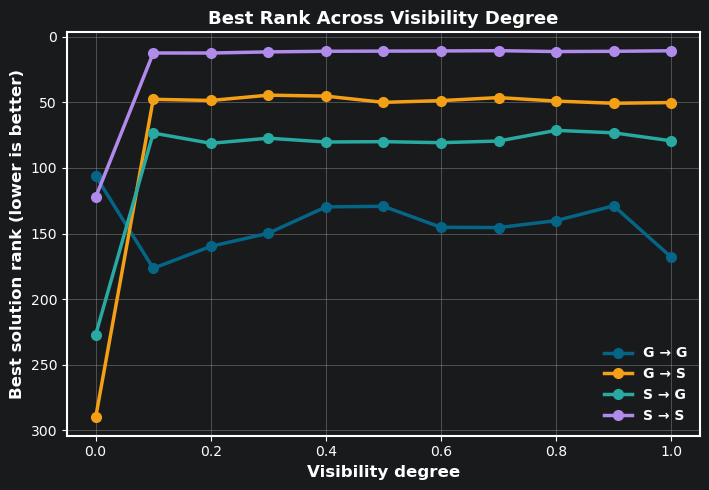

Saved: /Volumes/T7/data/gst-0112-26/Visibility_degree/figure_1_best_rank_across_visibility_degree_four_conditions.png
Saved: /Volumes/T7/data/gst-0112-26/Visibility_degree/figure_1_best_rank_across_visibility_degree_four_conditions.pdf


In [4]:
# =========================
# Figure 1: Four-line figure — best solution rank across visibility degree
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

for prefix in condition_order:
    # Average across K to show the main visibility-degree pattern.
    y = data[prefix]["breakthrough_rank"].mean(axis=1)
    ax.plot(
        x, y,
        marker="o", linewidth=2.5, markersize=7,
        label=condition_labels[prefix],
        color=condition_colors[prefix],
    )

ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Best Rank Across Visibility Degree", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)
plt.tight_layout()

output_png = result_folder / "figure_1_best_rank_across_visibility_degree_four_conditions.png"
output_pdf = result_folder / "figure_1_best_rank_across_visibility_degree_four_conditions.pdf"
plt.savefig(output_png, dpi=300, bbox_inches="tight")
plt.savefig(output_pdf, bbox_inches="tight")
plt.show()
print("Saved:", output_png)
print("Saved:", output_pdf)


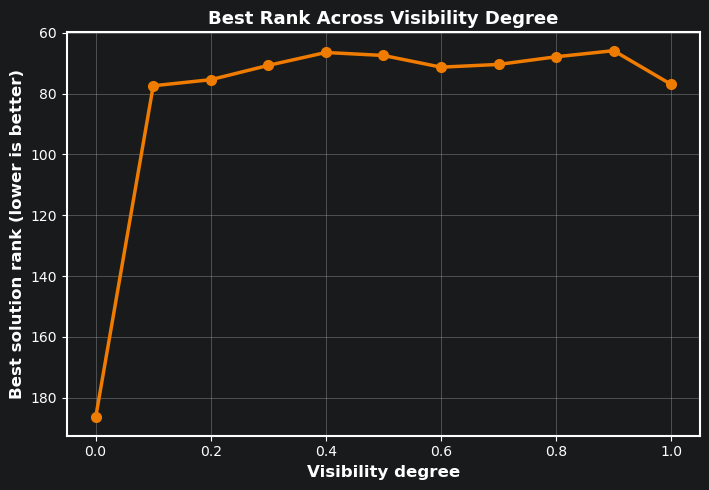

Saved: /Volumes/T7/data/gst-0112-26/Visibility_degree/figure_2_best_rank_across_visibility_degree_average_conditions.png


In [5]:
# =========================
# Figure 2: Averaged figure — best solution rank across visibility degree
# averaged across G-S combinations and K
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
format_axis(ax)

x = visibility_prob_list

# First average each condition across K; then average across the four G-S visibility conditions.
y = np.mean(
    [data[prefix]["breakthrough_rank"].mean(axis=1) for prefix in condition_order],
    axis=0,
)

ax.plot(x, y, marker="o", linewidth=2.5, markersize=7, color=nus_orange)

ax.invert_yaxis()
ax.set_xlabel("Visibility degree", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Best Rank Across Visibility Degree", fontweight="bold", fontsize=13)
plt.tight_layout()

output_png = result_folder / "figure_2_best_rank_across_visibility_degree_average_conditions.png"
plt.savefig(output_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Saved:", output_png)
